## CONFIDENCE INTERVALS
* CI = Point Estimate ± Margin of Error
* Margin of Error = Z × Standard Error
* Z = 1.96 (from standard normal distribution)
* CIs tell you not just “did it work?” but “how much impact can we expect?”
* In A/B Testing, CI helps in estimating uplift range, not just win/loss.

## Margin of Error (MOE)
* ↑ Sample size → ↓ MOE (more data = tighter range)
* ↑ Variability (std dev) → ↑ MOE
* ↑ Confidence level (e.g. 99%) → ↑ MOE (more certainty = wider net)



### CI for Mean (e.g. Avg. Spend per Customer)

In [1]:
# ===========================================
# CONFIDENCE INTERVAL FOR MEAN – Avg. Spend
# Business Framing:
# Estimating true avg. customer spend based on a sample.
# CI tells us: "What is the likely range of actual avg. spend?"
# Assumptions: Normality or large n, independent samples
# ===========================================

In [2]:
import numpy as np
import scipy.stats as stats

# Sample: Daily spend (₹) of 100 customers on a FinTech app
np.random.seed(42)
sample_spend = np.random.normal(loc=500, scale=60, size=100)  # Mean=500, SD=60

# Point estimate (sample mean)
mean_spend = np.mean(sample_spend)

# Standard Error
se = stats.sem(sample_spend)  # sem = std / sqrt(n)

# 95% CI
confidence = 0.95
z_score = stats.norm.ppf((1 + confidence) / 2)  # ~1.96
margin_of_error = z_score * se

ci_lower = mean_spend - margin_of_error
ci_upper = mean_spend + margin_of_error

print(f"📊 95% Confidence Interval for Avg. Spend: ₹{ci_lower:.2f} to ₹{ci_upper:.2f}")

📊 95% Confidence Interval for Avg. Spend: ₹483.09 to ₹504.45


This helps your business team understand whether marketing uplift is truly profitable or just noise.


### CI for Proportion (e.g. Conversion Rate)

In [3]:
# CONFIDENCE INTERVAL FOR PROPORTION – Conversion Rate
# Business Framing:
# Estimating real conversion rate from a signup funnel
# CI helps us avoid overconfidence from small sample size
# Assumptions: Binomial data, large enough n

In [4]:
# Sample: Out of 200 users, 54 signed up
n = 200
successes = 54
p_hat = successes / n

# Standard Error
se = np.sqrt(p_hat * (1 - p_hat) / n)

# 95% CI
z_score = stats.norm.ppf(0.975)
margin_of_error = z_score * se

ci_lower = p_hat - margin_of_error
ci_upper = p_hat + margin_of_error

print(f"📊 95% CI for Conversion Rate: {ci_lower:.3f} to {ci_upper:.3f} ({ci_lower*100:.1f}% to {ci_upper*100:.1f}%)")

📊 95% CI for Conversion Rate: 0.208 to 0.332 (20.8% to 33.2%)


## Law of Large Numbers (LLN)
* As sample size increases, the **sample mean stabilizes near the population mean**.
* A small n gives you high variance — **insights are shaky** or vice versa
* LLN reminds us that **consistency over scale matters more** than short-term patterns.

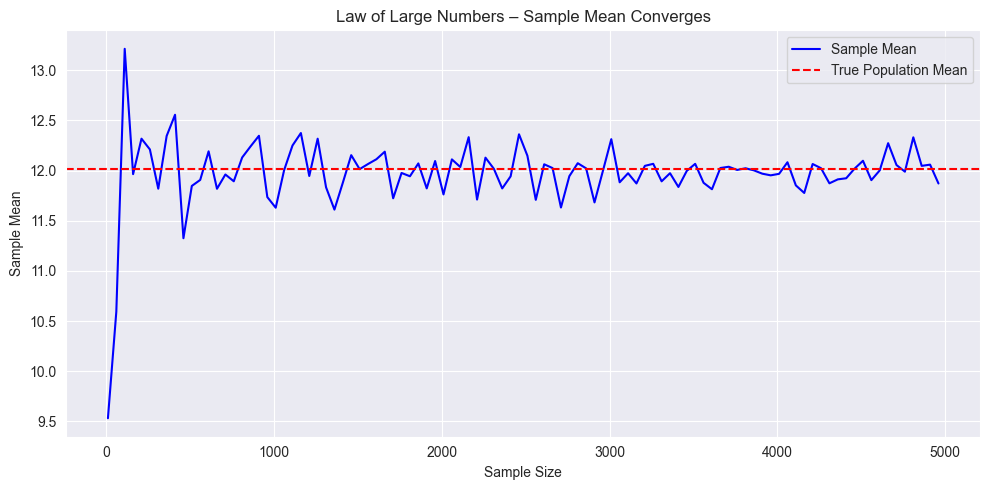

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate a population of repayment times (months)
# Gamma distribution to make it skewed (not normal)
population = np.random.gamma(shape=2.0, scale=6.0, size=100_000)  # mean ≈ 12

# Track sample means as we increase the sample size
sample_sizes = np.arange(10, 5000, 50)
sample_means = []

for n in sample_sizes:
    sample = np.random.choice(population, size=n, replace=False)
    sample_means.append(np.mean(sample))

# True population mean
true_mean = np.mean(population)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, sample_means, label="Sample Mean", color='blue')
plt.axhline(y=true_mean, color='red', linestyle='--', label="True Population Mean")
plt.title("Law of Large Numbers – Sample Mean Converges")
plt.xlabel("Sample Size")
plt.ylabel("Sample Mean")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation
* Early sample means fluctuate a lot.
* As sample size increases, they flatten and stabilize near the red line (true mean).
* That’s LLN: randomness fades, and signal wins.

## CENTRAL LIMIT THEOREM (CLT)
* what ? sampling distribution of the sample mean will approach a normal distribution as the sample size increases
* why ? backbone of confidence intervals, A/B testing, control/treatment design, and inferential statistics.
* when? to estimate population mean or do hypothesis testing on means.
* Assumptions : independence , sample size > n, finite variance

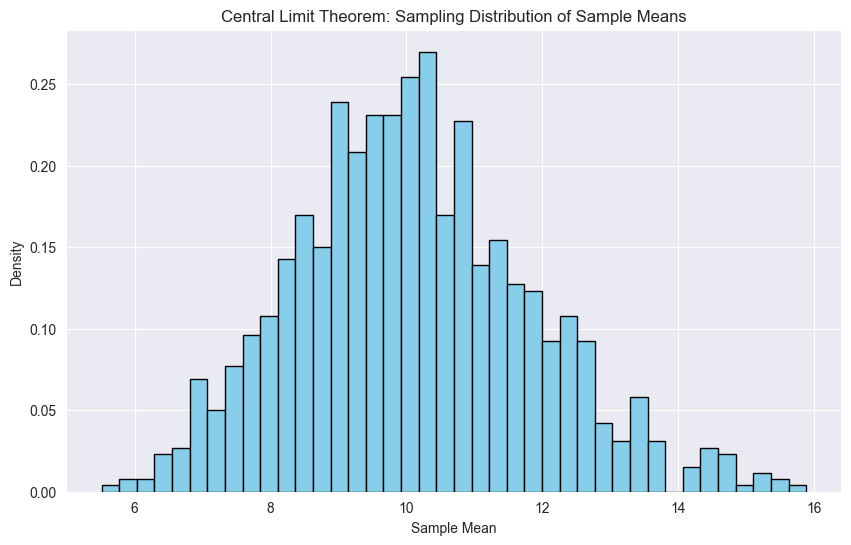

In [8]:
#---------------------------------------------
# Central Limit Theorem Simulation
# Concept: Sample means from exponential data → normal dist
# Business Framing: Estimating avg call duration from samples
# Assumptions: Samples are random, independent, n ≥ 30
# ---------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Simulate non-normal population (Exponential)
np.random.seed(42)
population = np.random.exponential(scale=10, size=100000)

# Draw 1000 samples of size 30 and store their means
sample_size = 30
num_samples = 1000
sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Plotting
plt.figure(figsize=(10,6))
plt.hist(sample_means, bins=40, color='skyblue', edgecolor='black', density=True)
plt.title("Central Limit Theorem: Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.grid(True)
plt.show()

Even though the original population is skewed (exponential), the sample means follow a normal distribution.

→ This enables you to apply z-tests or build confidence intervals on mean estimates.

## A/B testing
### We’re testing if a reminder at 10am improves bill payment rate.
###  **Logic**
* Split population randomly
→ Group A (Control)
→ Group B (Variant)
* Run the experiment over a time window (min 1–2 weeks in consumer apps).
* Measure performance of the key metric in both groups.
* Statistical test
→ Use t-test for mean differences (e.g., avg revenue per user)
→ Use z-test or chi-square for proportions (e.g., conversion rate)
* Interpret using Confidence Interval & p-value
→ If p < 0.05, the difference is statistically significant.



In [10]:
# ---------------------------------------------
# A/B TEST: Two-proportion Z-Test for Conversion Rate
# Business Framing: Does 10am reminder improve bill payment rate?
# Assumptions: Independent samples, large sample size (np > 10), binary outcome
# ---------------------------------------------

import statsmodels.api as sm

# Inputs
control_success = 3000
control_total = 5000
variant_success = 3450
variant_total = 5000

# Proportions
control_rate = control_success / control_total
variant_rate = variant_success / variant_total

# Summary
print(f"Control Rate: {control_rate:.2%}")
print(f"Variant Rate: {variant_rate:.2%}")

# Z-Test for proportions
count = [control_success, variant_success]
nobs = [control_total, variant_total]

z_stat, p_value = sm.stats.proportions_ztest(count, nobs)

# Interpretation
print(f"\nZ-Statistic: {z_stat:.3f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant: Reminder increases bill payment rate.")
else:
    print("❌ Not statistically significant: No strong evidence of impact.")

Control Rate: 60.00%
Variant Rate: 69.00%

Z-Statistic: -9.404
P-Value: 0.0000
✅ Statistically significant: Reminder increases bill payment rate.


Output Meaning:
Z-statistic: How far the difference is from 0 in standard errors

P-value: Probability that the observed difference is due to chance

If p < 0.05, the difference is statistically significant

## A/B Testing: Compare conversion rates of control vs variant
* After running the test, we analyze the outcome using statistical inference to determine if the observed difference is real or just random noise.
* To inter[ret results we use (H₀) vs (H₁) -> test type (z test or test) -> p-value -> CI -> significance level (α)
*  When to Say a Result is Statistically Significant:
    * If p-value < 0.05 → Reject H₀ → Variant performs significantly differently
    * If p-value ≥ 0.05 → Fail to reject H₀ → No confident difference

In [11]:
# A/B Testing: Compare conversion rates of control vs variant

import numpy as np
from scipy import stats

# Sample data
control = np.array([1]*200 + [0]*800)     # 20% conversion (200/1000)
variant = np.array([1]*260 + [0]*740)     # 26% conversion (260/1000)

# Perform two-sample t-test (alternative='two-sided' by default)
t_stat, p_val = stats.ttest_ind(control, variant)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Decision
if p_val < 0.05:
    print("Result is statistically significant: Reject Null Hypothesis")
else:
    print("Result is not significant: Fail to reject Null Hypothesis")


T-statistic: -3.1946
P-value: 0.0014
Result is statistically significant: Reject Null Hypothesis


## Probabilistic Package Estimator (Casual)

### Assumption: Execution, GitHub portfolio, and strong communication will be shown clearly through real-world projects and mock interviews.

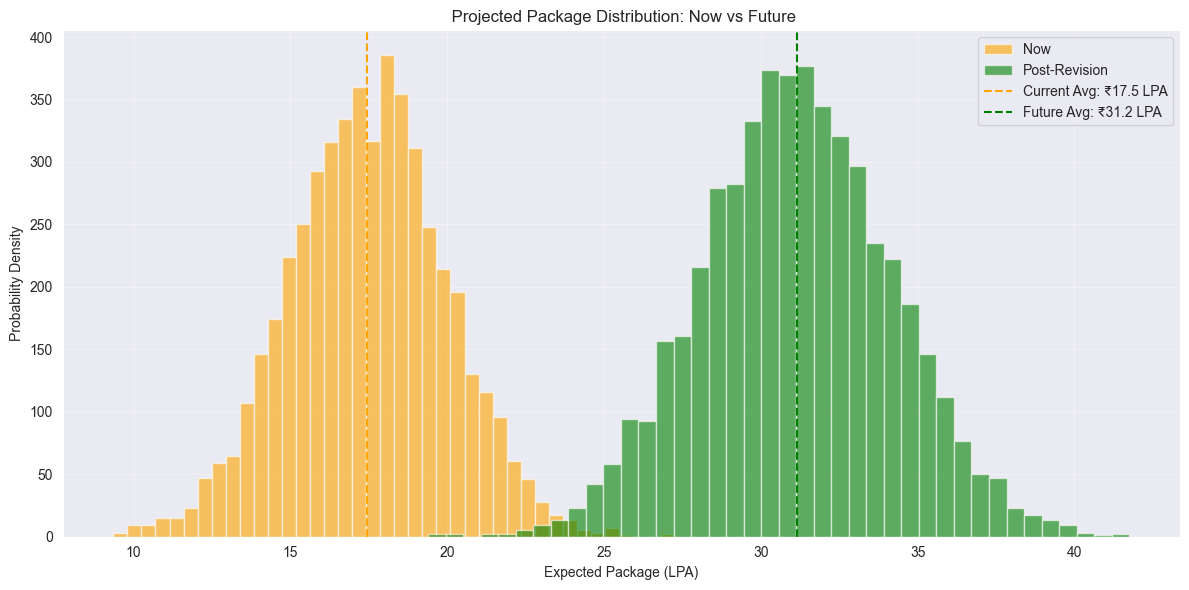

In [21]:
# Shiva's Performance Package Forecast Simulator

import numpy as np
import matplotlib.pyplot as plt

# Performance weights
weights = {
    'stats': 0.30,
    'ml': 0.30,
    'projects': 0.25,
    'business': 0.15
}

# Scores now (0-10 scale)
current_scores = {
    'stats': 8.5,
    'ml': 0,
    'projects': 2,
    'business': 6
}

# After 3 cycles of revision + ML + Projects
future_scores = {
    'stats': 9.5,
    'ml': 8.5,
    'projects': 8,
    'business': 8.5
}

# Normalized score function
def weighted_score(scores):
    return sum(scores[key] * weights[key] for key in scores)

# Current vs Future
now = weighted_score(current_scores)
future = weighted_score(future_scores)

# Map score (0–10) to package (in LPA)
def score_to_package(score):
    base = 6  # base offer
    peak = 35 # max offer with top-tier companies
    return base + (peak - base) * (score / 10)

# Simulate with randomness
np.random.seed(42)
samples = 5000
current_outcomes = np.random.normal(loc=score_to_package(now), scale=2.5, size=samples)
future_outcomes = np.random.normal(loc=score_to_package(future), scale=3.0, size=samples)

# Plot
plt.figure(figsize=(12, 6))
plt.hist(current_outcomes, bins=40, alpha=0.6, label="Now", color='orange')
plt.hist(future_outcomes, bins=40, alpha=0.6, label="Post-Revision", color='green')
plt.axvline(score_to_package(now), color='orange', linestyle='--', label=f'Current Avg: ₹{score_to_package(now):.1f} LPA')
plt.axvline(score_to_package(future), color='green', linestyle='--', label=f'Future Avg: ₹{score_to_package(future):.1f} LPA')
plt.title(" Projected Package Distribution: Now vs Future")
plt.xlabel("Expected Package (LPA)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()